# 한국어 독성 댓글 탐지 모델 학습 및 평가 (CPU 경량 버전)
### KOLD 데이터셋 + 한국어 ELECTRA 기반 이진 분류

이 노트북은 **노트북 CPU 환경에서도 끝까지 학습 가능한 경량 버전**을 기준으로 작성되었습니다.

- **데이터셋 요약과 라벨링 방식**을 명확히 기록
- **학습 전략과 기본 모델**을 구조적으로 정리
- **실제값 vs 예측값(Actual vs Predicted)**, **Confusion Matrix**, **ROC Curve**, **학습 곡선**을 산출
- **Streamlit Cloud 서비스용 아티팩트**를 함께 저장
- 원본 KOLD 전체 규모와 **실제 학습에 사용한 축소 샘플 규모**를 함께 기록

최종 산출물은 아래 폴더에 저장됩니다.
- `artifacts/model/` : 저장된 토크나이저/모델
- `artifacts/images/` : 시각화 이미지
- `artifacts/data/` : 예측 결과 CSV, 지표 JSON, 요약 정보


## 1. 프로젝트 개요 및 목표

### 프로젝트 목표
한국어 댓글을 **정상(normal)** 과 **독성(toxic)** 으로 분류하는 딥러닝 기반 텍스트 분류 모델을 구축한다.

### 해결하려는 문제
- 실시간 방송, 커뮤니티, 채팅 환경에서 공격적·비하적 댓글이 빠르게 확산될 수 있음
- 단순 욕설 사전 매칭만으로는 **암시적 공격 표현**을 충분히 다루기 어려움
- 한국어 댓글 도메인에 맞는 사전학습 언어모델을 활용해 자동 탐지 성능을 확보하고자 함

### 최종 결과물
- 한국어 독성 댓글 이진 분류 모델
- Streamlit Cloud 시연용 서비스 코드
- 성능 평가 시각화 결과물

## 2. 데이터셋 설명 및 라벨링 방식

### 사용 데이터셋
- **KOLD (Korean Offensive Language Dataset)**
- Hugging Face `load_dataset("nayohan/KOLD")` 로 로드

### 입력 컬럼
- `comment` : 실제 댓글 본문

### 라벨링 방식
- `OFF == True` → `toxic`
- `OFF == False` → `normal`

### 분할 전략
- 원본 train split을 사용한 뒤
- **Stratified 8:1:1 분할**로 `train / validation / test` 구성

### CPU 경량 학습 전략
- 원본 KOLD 전체 규모는 유지해서 요약 정보에 기록
- 실제 학습은 **축소 샘플(train/validation/test limit)** 만 사용
- 기본 모델은 **한국어 댓글 도메인에 적합한 ELECTRA small 계열**
- `max_length=64`, `epoch=1` 기준으로 빠르게 베이스라인을 확보


## 3. 기본 설정 및 라이브러리
> 처음 실행하는 환경이라면 아래 주석의 pip 명령을 먼저 실행하세요.
>
> `pip install datasets transformers torch scikit-learn pandas matplotlib streamlit accelerate`

In [1]:
# !pip install datasets transformers torch scikit-learn pandas matplotlib streamlit accelerate

from __future__ import annotations

import inspect
import json
import math
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from datasets import DatasetDict, load_dataset
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
    roc_auc_score,
    roc_curve,
)
from sklearn.utils.class_weight import compute_class_weight
from torch import nn
from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    DataCollatorWithPadding,
    EarlyStoppingCallback,
    Trainer,
    TrainingArguments,
)

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False
pd.options.display.max_colwidth = 200

d:\git\project_week3\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 4. 하이퍼파라미터 및 저장 경로
- 기본 모델은 **`beomi/KcELECTRA-small-v2022`**
- CPU 기준 학습 시간을 줄이기 위해 **데이터셋 축소 학습**을 기본값으로 사용
- 필요하면 제한 수를 늘려서 성능을 다시 높일 수 있음


In [2]:
SEED = 42
MODEL_NAME = "beomi/KcELECTRA-small-v2022"
MAX_LENGTH = 64
TRAIN_BATCH_SIZE = 8
EVAL_BATCH_SIZE = 8
LEARNING_RATE = 2e-5
NUM_EPOCHS = 1
WEIGHT_DECAY = 0.01
EARLY_STOPPING_PATIENCE = 2

# CPU 경량 학습용 샘플 제한
TRAIN_LIMIT = 3000
VALID_LIMIT = 500
TEST_LIMIT = 500

ARTIFACT_ROOT = Path("artifacts")
MODEL_DIR = ARTIFACT_ROOT / "model"
IMAGE_DIR = ARTIFACT_ROOT / "images"
DATA_DIR = ARTIFACT_ROOT / "data"

ARTIFACT_ROOT.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)
IMAGE_DIR.mkdir(parents=True, exist_ok=True)
DATA_DIR.mkdir(parents=True, exist_ok=True)

LABEL_MAP = {0: "normal", 1: "toxic"}
INV_LABEL_MAP = {v: k for k, v in LABEL_MAP.items()}


## 5. 데이터 로드 및 이진 라벨 변환

In [3]:
def _limit_split(ds, limit: int | None):
    if limit is None:
        return ds
    limit = min(limit, len(ds))
    return ds.shuffle(seed=SEED).select(range(limit))


def _dataset_to_df(ds, split_name: str) -> pd.DataFrame:
    df = ds.to_pandas().copy()
    df["split"] = split_name
    return df


def prepare_kold_dataset() -> tuple[DatasetDict, pd.DataFrame, pd.DataFrame, dict]:
    raw = load_dataset("nayohan/KOLD")
    base = raw["train"]

    def map_fn(example):
        return {
            "text": example["comment"],
            "label": int(bool(example["OFF"])),
            "title": example.get("title", ""),
            "source": example.get("source", ""),
        }

    mapped = base.map(map_fn)
    keep_cols = ["text", "label", "title", "source"]
    mapped = mapped.remove_columns([c for c in mapped.column_names if c not in keep_cols])

    full_overview_df = mapped.to_pandas().copy()
    mapped = mapped.class_encode_column("label")

    split_1 = mapped.train_test_split(
        test_size=0.2,
        seed=SEED,
        stratify_by_column="label",
    )
    split_2 = split_1["test"].train_test_split(
        test_size=0.5,
        seed=SEED,
        stratify_by_column="label",
    )

    full_dataset = DatasetDict(
        {
            "train": split_1["train"],
            "validation": split_2["train"],
            "test": split_2["test"],
        }
    )

    limited_dataset = DatasetDict(
        {
            "train": _limit_split(full_dataset["train"], TRAIN_LIMIT),
            "validation": _limit_split(full_dataset["validation"], VALID_LIMIT),
            "test": _limit_split(full_dataset["test"], TEST_LIMIT),
        }
    )

    used_overview_df = pd.concat(
        [
            _dataset_to_df(limited_dataset["train"], "train"),
            _dataset_to_df(limited_dataset["validation"], "validation"),
            _dataset_to_df(limited_dataset["test"], "test"),
        ],
        ignore_index=True,
    )

    meta = {
        "full_train_samples": len(full_dataset["train"]),
        "full_validation_samples": len(full_dataset["validation"]),
        "full_test_samples": len(full_dataset["test"]),
        "used_train_samples": len(limited_dataset["train"]),
        "used_validation_samples": len(limited_dataset["validation"]),
        "used_test_samples": len(limited_dataset["test"]),
    }

    return limited_dataset, full_overview_df, used_overview_df, meta


dataset, full_overview_df, overview_df, dataset_meta = prepare_kold_dataset()
print(dataset)
overview_df.head()


DatasetDict({
    train: Dataset({
        features: ['source', 'title', 'text', 'label'],
        num_rows: 3000
    })
    validation: Dataset({
        features: ['source', 'title', 'text', 'label'],
        num_rows: 500
    })
    test: Dataset({
        features: ['source', 'title', 'text', 'label'],
        num_rows: 500
    })
})


,source,title,text,label,split
0,naver_news,"국민의힘, 여성 지지율 급락·남성 지지율은 보합... '이남자 전략' 실패?",정권교체는 글러먹었다,1,train
1,youtube,크리스천의 혼전순결에 대해서 생각해봤습니다 강남대 기독교학과 백소영 교수 잘잘법 Ep.82,말세다말세...죄는 죄라고 가르쳐야지요.,0,train
2,naver_news,"파키스탄군 ""인도서 쏜 비무장 초음속 발사체 영토 내 떨어져""",하.. 너도나도 폭탄자랑질. 이때 한번 죽어보고 싶구나,1,train
3,youtube,유해석 박사의 이슬람 특강 - 영국의 브렉시트와 이슬람에 대한 관계?,교수님의 강의는 지금의 한국정부가 새겨 듣고 정책과 법안에 반영해야 된다고 봅니다!,0,train
4,youtube,총격당한 흑인 아빠 '하반신 마비' 미국 시위 격화 / SBS,"물론 저 상황 경찰 잘못이긴 한데 극단 인종차별로 몰아가는건 좀.. 통계를 봐도 미국에서 비무장 백인이 경찰한테 총격을 당하는게 흑인의 4배가 넘는데, 마치 흑인만 그렇다고 보도하니깐 인종차별 시위로 확산되는거지",0,train


## 6. 데이터셋 요약

In [4]:
summary = {
    "full_total_samples": len(full_overview_df),
    "total_samples": len(overview_df),
    "train_samples": len(dataset["train"]),
    "validation_samples": len(dataset["validation"]),
    "test_samples": len(dataset["test"]),
    "full_split_samples": {
        "train": dataset_meta["full_train_samples"],
        "validation": dataset_meta["full_validation_samples"],
        "test": dataset_meta["full_test_samples"],
    },
    "used_split_samples": {
        "train": dataset_meta["used_train_samples"],
        "validation": dataset_meta["used_validation_samples"],
        "test": dataset_meta["used_test_samples"],
    },
    "label_distribution": overview_df["label"].value_counts().sort_index().to_dict(),
    "full_label_distribution": full_overview_df["label"].value_counts().sort_index().to_dict(),
}

summary["label_distribution_named"] = {
    LABEL_MAP[int(k)]: int(v) for k, v in summary["label_distribution"].items()
}
summary["full_label_distribution_named"] = {
    LABEL_MAP[int(k)]: int(v) for k, v in summary["full_label_distribution"].items()
}

summary_df = pd.DataFrame(
    {
        "구분": ["원본 전체", "실사용 전체", "학습", "검증", "테스트"],
        "샘플 수": [
            summary["full_total_samples"],
            summary["total_samples"],
            summary["train_samples"],
            summary["validation_samples"],
            summary["test_samples"],
        ],
    }
)

display(summary_df)
display(
    overview_df[["text", "label", "source", "split"]]
    .assign(label_name=lambda x: x["label"].map(LABEL_MAP))
    .sample(min(5, len(overview_df)), random_state=SEED)
    .reset_index(drop=True)
)

with open(DATA_DIR / "dataset_summary.json", "w", encoding="utf-8") as f:
    json.dump(summary, f, ensure_ascii=False, indent=2)


,구분,샘플 수
0,원본 전체,40429
1,실사용 전체,4000
2,학습,3000
3,검증,500
4,테스트,500


,text,label,source,split,label_name
0,제발 기사좀 보면서 살아 ㅋㅋ좌표찍힌 기사만 보지말고 ㅋㅋ,1,naver_news,train,toxic
1,안산이 문제야 국대란게 할말과 하지 말아야할 말 가리지도 않고 남성형모 단어를 사용한건 문제지.,1,naver_news,validation,toxic
2,지 아버지 한테도 한남이라 하겠지?당신 가족들은 당신이 이러는지 알어?까놓고 가족한테 나 페미임 했으면더이상 말안함 쌉인정,1,naver_news,train,toxic
3,다른 나라 가라고해 땅도 좁은데 무슨...ㅡ.ㅡ,1,naver_news,test,toxic
4,어휴 숨막혀서 못살것다,1,youtube,train,toxic


## 7. 라벨 분포 시각화

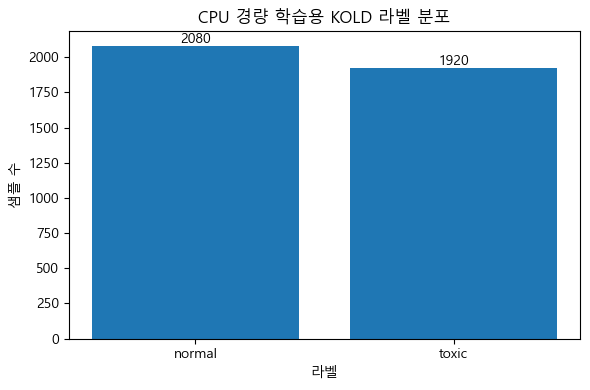

In [5]:
label_counts = overview_df["label"].value_counts().sort_index()
label_names = [LABEL_MAP[idx] for idx in label_counts.index]

plt.figure(figsize=(6, 4))
bars = plt.bar(label_names, label_counts.values)
plt.title("CPU 경량 학습용 KOLD 라벨 분포")
plt.xlabel("라벨")
plt.ylabel("샘플 수")
for bar, value in zip(bars, label_counts.values):
    plt.text(bar.get_x() + bar.get_width() / 2, value, f"{value}", ha="center", va="bottom")
plt.tight_layout()
plt.savefig(IMAGE_DIR / "label_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

label_distribution_df = pd.DataFrame({"label": label_names, "count": label_counts.values})
label_distribution_df.to_csv(DATA_DIR / "label_distribution.csv", index=False, encoding="utf-8-sig")


## 8. 토크나이저 및 토크나이징

In [6]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_function(examples):
    return tokenizer(
        examples["text"],
        truncation=True,
        max_length=MAX_LENGTH,
    )

tokenized = dataset.map(tokenize_function, batched=True)
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)
tokenized

DatasetDict({
    train: Dataset({
        features: ['source', 'title', 'text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 3000
    })
    validation: Dataset({
        features: ['source', 'title', 'text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 500
    })
    test: Dataset({
        features: ['source', 'title', 'text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 500
    })
})

## 9. 학습 전략 및 기본 모델

### 기본 모델
- `beomi/KcELECTRA-small-v2022`

### 선택 이유
- 한국어 댓글/구어체 환경에 비교적 적합한 ELECTRA 계열
- base보다 작아서 CPU 환경에서도 실험 가능성이 높음
- Streamlit 서비스 배포 시 로딩 부담을 다소 줄일 수 있음

### 학습 전략
- Stratified split
- Weighted Cross Entropy
- Early Stopping
- Best checkpoint 기준 저장

In [7]:
train_labels = np.array(dataset["train"]["label"])
classes = np.array([0, 1])
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=train_labels,
)
class_weights = torch.tensor(class_weights, dtype=torch.float)
class_weights

tensor([0.9640, 1.0388])

In [8]:
def build_training_args() -> TrainingArguments:
    signature = inspect.signature(TrainingArguments.__init__)
    kwargs = {
        "output_dir": str(ARTIFACT_ROOT / "checkpoints"),
        "learning_rate": LEARNING_RATE,
        "per_device_train_batch_size": TRAIN_BATCH_SIZE,
        "per_device_eval_batch_size": EVAL_BATCH_SIZE,
        "num_train_epochs": NUM_EPOCHS,
        "weight_decay": WEIGHT_DECAY,
        "save_total_limit": 1,
        "load_best_model_at_end": True,
        "metric_for_best_model": "f1",
        "greater_is_better": True,
        "logging_steps": 20,
        "report_to": "none",
        "dataloader_num_workers": 0,
    }

    if "eval_strategy" in signature.parameters:
        kwargs["eval_strategy"] = "epoch"
    else:
        kwargs["evaluation_strategy"] = "epoch"

    if "save_strategy" in signature.parameters:
        kwargs["save_strategy"] = "epoch"

    if "logging_strategy" in signature.parameters:
        kwargs["logging_strategy"] = "steps"

    if "use_cpu" in signature.parameters and not torch.cuda.is_available():
        kwargs["use_cpu"] = True

    if "save_safetensors" in signature.parameters:
        kwargs["save_safetensors"] = True

    return TrainingArguments(**kwargs)


def softmax_np(logits: np.ndarray) -> np.ndarray:
    logits = logits - logits.max(axis=1, keepdims=True)
    exp = np.exp(logits)
    return exp / exp.sum(axis=1, keepdims=True)


def compute_metrics(eval_pred):
    logits, labels = eval_pred
    probs = softmax_np(logits)
    preds = np.argmax(probs, axis=1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, preds, average="binary", zero_division=0
    )
    acc = accuracy_score(labels, preds)

    try:
        auc = roc_auc_score(labels, probs[:, 1])
    except ValueError:
        auc = float("nan")

    return {
        "accuracy": float(acc),
        "precision": float(precision),
        "recall": float(recall),
        "f1": float(f1),
        "roc_auc": float(auc) if not math.isnan(auc) else None,
    }


class WeightedTrainer(Trainer):
    def __init__(self, *args, class_weights: torch.Tensor | None = None, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.get("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")

        if self.class_weights is None:
            loss = outputs.get("loss")
        else:
            loss_fct = nn.CrossEntropyLoss(weight=self.class_weights.to(logits.device))
            loss = loss_fct(logits.view(-1, model.config.num_labels), labels.view(-1))

        return (loss, outputs) if return_outputs else loss


## 10. 모델 학습

In [9]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,
    id2label=LABEL_MAP,
    label2id=INV_LABEL_MAP,
)

training_args = build_training_args()

trainer_kwargs = {
    # 1 epoch CPU 경량 학습에서는 EarlyStoppingCallback을 사용하지 않음
    "model": model,
    "args": training_args,
    "train_dataset": tokenized["train"],
    "eval_dataset": tokenized["validation"],
    "data_collator": data_collator,
    "compute_metrics": compute_metrics,
    "class_weights": class_weights,
}

trainer_signature = inspect.signature(Trainer.__init__)
if "processing_class" in trainer_signature.parameters:
    trainer_kwargs["processing_class"] = tokenizer
else:
    trainer_kwargs["tokenizer"] = tokenizer

trainer = WeightedTrainer(**trainer_kwargs)

train_result = trainer.train()
train_result

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 27890.08it/s]
ElectraForSequenceClassification LOAD REPORT from: beomi/KcELECTRA-small-v2022
Key                                               | Status     | 
--------------------------------------------------+------------+-
discriminator_predictions.dense_prediction.bias   | UNEXPECTED | 
discriminator_predictions.dense.bias              | UNEXPECTED | 
discriminator_predictions.dense_prediction.weight | UNEXPECTED | 
discriminator_predictions.dense.weight            | UNEXPECTED | 
electra.embeddings.position_ids                   | UNEXPECTED | 
classifier.out_proj.weight                        | MISSING    | 
classifier.dense.bias                             | MISSING    | 
classifier.out_proj.bias                          | MISSING    | 
classifier.dense.weight                           | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MI

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Roc Auc
1,0.659414,0.638248,0.776000,0.735409,0.811159,0.771429,0.850444


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  7.90it/s]
There were missing keys in the checkpoint model loaded: ['electra.embeddings.LayerNorm.weight', 'electra.embeddings.LayerNorm.bias', 'electra.encoder.layer.0.attention.output.LayerNorm.weight', 'electra.encoder.layer.0.attention.output.LayerNorm.bias', 'electra.encoder.layer.0.output.LayerNorm.weight', 'electra.encoder.layer.0.output.LayerNorm.bias', 'electra.encoder.layer.1.attention.output.LayerNorm.weight', 'electra.encoder.layer.1.attention.output.LayerNorm.bias', 'electra.encoder.layer.1.output.LayerNorm.weight', 'electra.encoder.layer.1.output.LayerNorm.bias', 'electra.encoder.layer.2.attention.output.LayerNorm.weight', 'electra.encoder.layer.2.attention.output.LayerNorm.bias', 'electra.encoder.layer.2.output.LayerNorm.weight', 'electra.encoder.layer.2.output.LayerNorm.bias', 'electra.encoder.layer.3.attention.output.LayerNorm.weight', 'electra.encoder.layer.3.attention.output.LayerNorm.bias', 'electra.encoder.la

TrainOutput(global_step=375, training_loss=0.6773515192667643, metrics={'train_runtime': 182.5852, 'train_samples_per_second': 16.431, 'train_steps_per_second': 2.054, 'total_flos': 7524532824672.0, 'train_loss': 0.6773515192667643, 'epoch': 1.0})

## 11. 검증/테스트 성능 평가

In [10]:
def compute_split_metrics_from_prediction_output(pred_output):
    logits = pred_output.predictions
    labels = np.array(pred_output.label_ids)
    probs = softmax_np(logits)
    preds = np.argmax(probs, axis=1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, preds, average="binary", zero_division=0
    )
    acc = accuracy_score(labels, preds)

    try:
        auc = roc_auc_score(labels, probs[:, 1])
    except ValueError:
        auc = float("nan")

    metrics = {
        "eval_accuracy": float(acc),
        "eval_precision": float(precision),
        "eval_recall": float(recall),
        "eval_f1": float(f1),
        "eval_roc_auc": float(auc),
    }
    return metrics, probs, preds, labels


val_pred_output = trainer.predict(tokenized["validation"])
val_metrics, val_probs, val_preds, val_labels = compute_split_metrics_from_prediction_output(val_pred_output)

test_pred_output = trainer.predict(tokenized["test"])
test_metrics, test_probs, test_preds, test_labels = compute_split_metrics_from_prediction_output(test_pred_output)

metrics_bundle = {
    "model_name": MODEL_NAME,
    "max_length": MAX_LENGTH,
    "train_batch_size": TRAIN_BATCH_SIZE,
    "eval_batch_size": EVAL_BATCH_SIZE,
    "learning_rate": LEARNING_RATE,
    "num_epochs": NUM_EPOCHS,
    "validation_metrics": val_metrics,
    "test_metrics": test_metrics,
}

with open(DATA_DIR / "metrics.json", "w", encoding="utf-8") as f:
    json.dump(metrics_bundle, f, ensure_ascii=False, indent=2)

pd.DataFrame(
    [
        {"split": "validation", **val_metrics},
        {"split": "test", **test_metrics},
    ]
)


,split,eval_accuracy,eval_precision,eval_recall,eval_f1,eval_roc_auc
0,validation,0.776,0.735409,0.811159,0.771429,0.850444
1,test,0.776,0.752896,0.802469,0.776892,0.859826


## 12. 테스트셋 예측 결과 생성

In [11]:
# 위 셀에서 이미 test_pred_output, test_probs, test_preds, test_labels를 계산한 상태를 재사용
# 커널을 새로 시작한 뒤 이 셀만 단독 실행하는 경우를 대비해 fallback 로직을 둡니다.
if "test_pred_output" not in globals():
    test_pred_output = trainer.predict(tokenized["test"])
    test_logits = test_pred_output.predictions
    test_probs = softmax_np(test_logits)
    test_preds = np.argmax(test_probs, axis=1)
    test_labels = np.array(test_pred_output.label_ids)

test_texts = list(dataset["test"]["text"])

pred_df = pd.DataFrame(
    {
        "text": test_texts,
        "actual": test_labels,
        "predicted": test_preds,
        "actual_label": [LABEL_MAP[int(x)] for x in test_labels],
        "predicted_label": [LABEL_MAP[int(x)] for x in test_preds],
        "prob_normal": test_probs[:, 0],
        "prob_toxic": test_probs[:, 1],
        "correct": test_labels == test_preds,
    }
)

pred_df.to_csv(DATA_DIR / "predictions_test.csv", index=False, encoding="utf-8-sig")
pred_df.head()


,text,actual,predicted,actual_label,predicted_label,prob_normal,prob_toxic,correct
0,ㄴ언제는 반미라며? 아이큐 한자리냐?,1,1,toxic,toxic,0.453632,0.546368,True
1,국민을 위로하는 종교의 힘을 알아주셔서 감사하고 특히 기독교의 가치와 헌신을 이해해주시는 듯 하여 반갑습니다. 차별금지법을 막아주시길 당부드립니다.,0,0,normal,normal,0.583336,0.416664,True
2,니부터 상식을 가지세요,1,1,toxic,toxic,0.469084,0.530916,True
3,송이가 조선족 비하한건 잘못한거다 법도 99명 도둑때문에 1명의 무고한 사람이 다쳐서는 안된다고 한다 특히 탈북시 조건없이 도와준 조선족,0,1,normal,toxic,0.460666,0.539334,False
4,2030 남자 2등시민도 아니고 4등시민 취급받고 이거 아니다 싶어 뭐라했더니 못배운 사람 취급해서 단합된거 맞음 ㅇㅇ 계속 페미 표 먹겠다고 젠더 젠더 씨부려봐라 72퍼가 82퍼 되고 92퍼도 될거다 ㅋㅋ,1,1,toxic,toxic,0.459639,0.540361,True


## 13. 분류 리포트, 오분류 사례 저장

In [12]:
report_dict = classification_report(
    test_labels,
    test_preds,
    target_names=["normal", "toxic"],
    output_dict=True,
    zero_division=0,
)

with open(DATA_DIR / "classification_report.json", "w", encoding="utf-8") as f:
    json.dump(report_dict, f, ensure_ascii=False, indent=2)

false_positive_df = pred_df[(pred_df["actual"] == 0) & (pred_df["predicted"] == 1)].copy()
false_negative_df = pred_df[(pred_df["actual"] == 1) & (pred_df["predicted"] == 0)].copy()

false_positive_df.to_csv(DATA_DIR / "false_positives.csv", index=False, encoding="utf-8-sig")
false_negative_df.to_csv(DATA_DIR / "false_negatives.csv", index=False, encoding="utf-8-sig")

display(pd.DataFrame(report_dict).transpose())
display(false_positive_df.head(5))
display(false_negative_df.head(5))

,precision,recall,f1-score,support
normal,0.800830,0.750973,0.775100,257.000
toxic,0.752896,0.802469,0.776892,243.000
accuracy,0.776000,0.776000,0.776000,0.776
macro avg,0.776863,0.776721,0.775996,500.000
weighted avg,0.777534,0.776000,0.775971,500.000


,text,actual,predicted,actual_label,predicted_label,prob_normal,prob_toxic,correct
3,송이가 조선족 비하한건 잘못한거다 법도 99명 도둑때문에 1명의 무고한 사람이 다쳐서는 안된다고 한다 특히 탈북시 조건없이 도와준 조선족,0,1,normal,toxic,0.460666,0.539334,False
22,방탄사진은 왜여기??지민이는 뭘입어도어울림 이걸 일반화할수가업음 일반인들이 입기에는 힘든의상도 잘어울리는게연예인들이라서,0,1,normal,toxic,0.483325,0.516675,False
30,중국의 발빠른 대처에 박수를! 우리는 북한이 도발하고 포탄 쏘면 식량이나 돈 가져다 주는데.. 테러조직과 타협을 하면 안된다! 어차피 통일은 절대 불가능하다,0,1,normal,toxic,0.476100,0.523900,False
48,뭔소린지 하나도 모르겠다 ;;;,0,1,normal,toxic,0.484111,0.515889,False
56,근데 볍안이 잘 못됐으면 뭐가 잘못됐다는 건지 잘 모르겠네요 특정종교를 위한 법안일 것 같은면 왜 그렇게 생각하는지 이야기 좀 하고 논의 했으면 합니다,0,1,normal,toxic,0.474586,0.525414,False


,text,actual,predicted,actual_label,predicted_label,prob_normal,prob_toxic,correct
8,전문의 상담받으셔보길 추천드립니다,1,0,toxic,normal,0.581985,0.418015,False
9,정상적이네요,1,0,toxic,normal,0.583715,0.416285,False
19,동성애의 다수가 남성이며 핵심은 항문성관계입니다좁은 항문에 성관계를 하면 과연 괜찮을까요이걸 꼭 의학공부를 해야 아나요항문성관계가 괜찮으니까 권유해야하나요청소년과 청년들의 에이즈와 항문질환이 급증하고 있습니다 동성애의 보건적 위험성을 알려야만 합니다,1,0,toxic,normal,0.528224,0.471776,False
31,주민번호 t로 시작하게해줘 . 그래도 차별이라고 하겠지 정신병자들,1,0,toxic,normal,0.500002,0.499998,False
39,밖에서 대기타시길. 이준석이 깽판쳐서 결국 다 망쳐 놓으면 우린 안철수로 갈아탑니다.,1,0,toxic,normal,0.501691,0.498309,False


## 14. Confusion Matrix 시각화

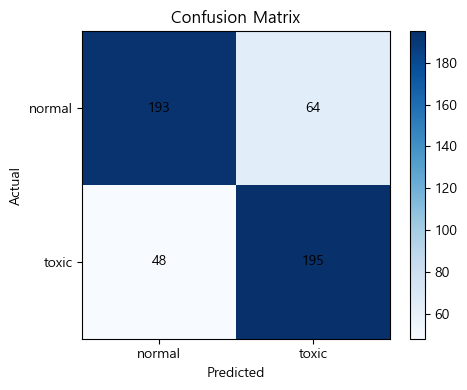

In [13]:
cm = confusion_matrix(test_labels, test_preds)

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap="Blues")
ax.set_title("Confusion Matrix")
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_xticks([0, 1], labels=["normal", "toxic"])
ax.set_yticks([0, 1], labels=["normal", "toxic"])

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j], ha="center", va="center", color="black")

fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.savefig(IMAGE_DIR / "confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

## 15. ROC Curve 시각화

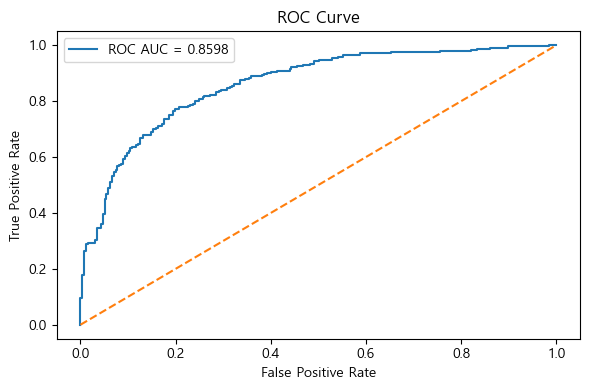

In [14]:
fpr, tpr, thresholds = roc_curve(test_labels, test_probs[:, 1])
roc_auc = roc_auc_score(test_labels, test_probs[:, 1])

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f"ROC AUC = {roc_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.savefig(IMAGE_DIR / "roc_curve.png", dpi=150, bbox_inches="tight")
plt.show()

## 16. Actual vs Predicted 시각화
> PPT/보고서에서 바로 사용할 수 있도록 `plt.show()` 기반 그래프를 생성합니다.

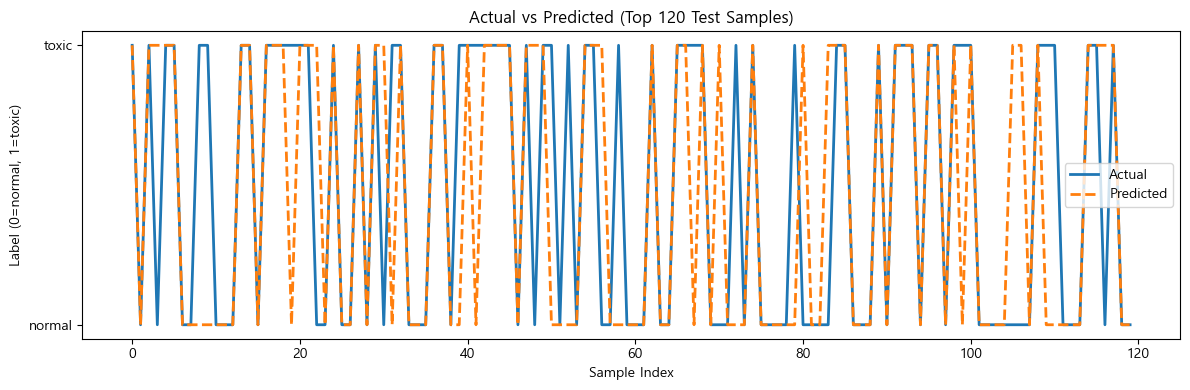

In [15]:
N_SAMPLES_TO_PLOT = min(120, len(pred_df))
plot_df = pred_df.head(N_SAMPLES_TO_PLOT).copy()

plt.figure(figsize=(12, 4))
plt.plot(plot_df.index, plot_df["actual"], label="Actual", linewidth=2)
plt.plot(plot_df.index, plot_df["predicted"], label="Predicted", linestyle="--", linewidth=2)
plt.title(f"Actual vs Predicted (Top {N_SAMPLES_TO_PLOT} Test Samples)")
plt.xlabel("Sample Index")
plt.ylabel("Label (0=normal, 1=toxic)")
plt.yticks([0, 1], ["normal", "toxic"])
plt.legend()
plt.tight_layout()
plt.savefig(IMAGE_DIR / "actual_vs_predicted.png", dpi=150, bbox_inches="tight")
plt.show()

## 17. 학습 곡선 시각화

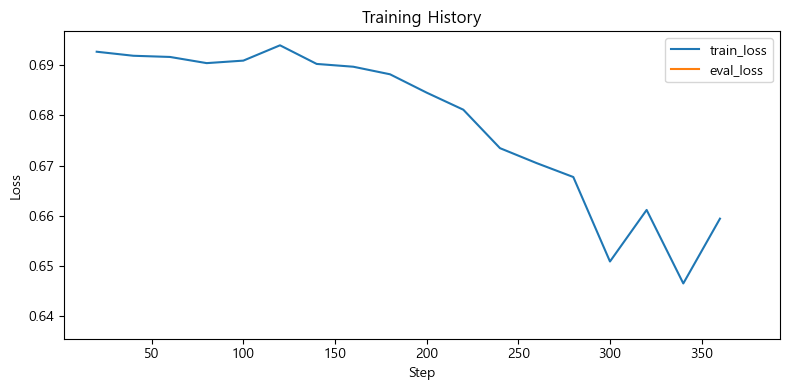

In [16]:
log_history = trainer.state.log_history
history_df = pd.DataFrame(log_history)
history_df.to_csv(DATA_DIR / "training_history.csv", index=False, encoding="utf-8-sig")

plot_history = history_df.copy()

plt.figure(figsize=(8, 4))
if "loss" in plot_history.columns:
    train_loss_df = plot_history.dropna(subset=["loss"])
    if not train_loss_df.empty:
        plt.plot(train_loss_df["step"], train_loss_df["loss"], label="train_loss")
if "eval_loss" in plot_history.columns:
    eval_loss_df = plot_history.dropna(subset=["eval_loss"])
    if not eval_loss_df.empty:
        plt.plot(eval_loss_df["step"], eval_loss_df["eval_loss"], label="eval_loss")

plt.title("Training History")
plt.xlabel("Step")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.savefig(IMAGE_DIR / "training_history.png", dpi=150, bbox_inches="tight")
plt.show()

## 18. 테스트셋 확률 분포 시각화

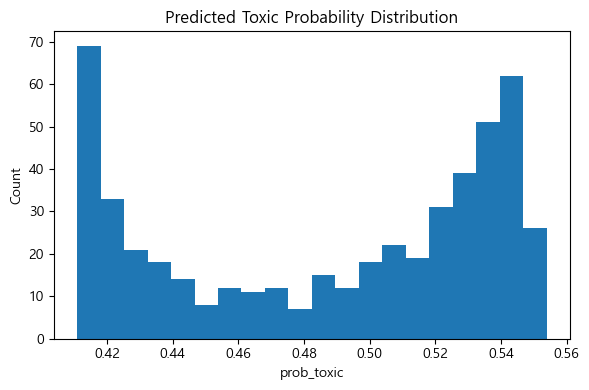

In [17]:
plt.figure(figsize=(6, 4))
plt.hist(pred_df["prob_toxic"], bins=20)
plt.title("Predicted Toxic Probability Distribution")
plt.xlabel("prob_toxic")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(IMAGE_DIR / "probability_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

## 19. 모델 및 토크나이저 저장

In [18]:
trainer.save_model(MODEL_DIR)
tokenizer.save_pretrained(MODEL_DIR)

artifact_manifest = {
    "model_dir": str(MODEL_DIR),
    "image_dir": str(IMAGE_DIR),
    "data_dir": str(DATA_DIR),
    "saved_files": sorted(
        [str(path.relative_to(ARTIFACT_ROOT)) for path in ARTIFACT_ROOT.rglob("*") if path.is_file()]
    ),
}

with open(DATA_DIR / "artifact_manifest.json", "w", encoding="utf-8") as f:
    json.dump(artifact_manifest, f, ensure_ascii=False, indent=2)

artifact_manifest

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  7.97it/s]


{'model_dir': 'artifacts\\model',
 'image_dir': 'artifacts\\images',
 'data_dir': 'artifacts\\data',
 'saved_files': ['checkpoints\\checkpoint-375\\config.json',
  'checkpoints\\checkpoint-375\\model.safetensors',
  'checkpoints\\checkpoint-375\\optimizer.pt',
  'checkpoints\\checkpoint-375\\rng_state.pth',
  'checkpoints\\checkpoint-375\\scheduler.pt',
  'checkpoints\\checkpoint-375\\tokenizer.json',
  'checkpoints\\checkpoint-375\\tokenizer_config.json',
  'checkpoints\\checkpoint-375\\trainer_state.json',
  'checkpoints\\checkpoint-375\\training_args.bin',
  'data\\classification_report.json',
  'data\\dataset_summary.json',
  'data\\false_negatives.csv',
  'data\\false_positives.csv',
  'data\\label_distribution.csv',
  'data\\metrics.json',
  'data\\predictions_test.csv',
  'data\\training_history.csv',
  'images\\actual_vs_predicted.png',
  'images\\confusion_matrix.png',
  'images\\label_distribution.png',
  'images\\probability_distribution.png',
  'images\\roc_curve.png',
  'i

## 20. Streamlit 서비스 연동 체크
아래 파일들이 생성되었으면 Streamlit 서비스에서 바로 재사용할 수 있습니다.

- `artifacts/model/`
- `artifacts/data/metrics.json`
- `artifacts/data/classification_report.json`
- `artifacts/data/predictions_test.csv`
- `artifacts/images/confusion_matrix.png`
- `artifacts/images/roc_curve.png`
- `artifacts/images/actual_vs_predicted.png`
- `artifacts/images/training_history.png`

In [19]:
for path in sorted(ARTIFACT_ROOT.rglob("*")):
    print(path)

artifacts\checkpoints
artifacts\checkpoints\checkpoint-375
artifacts\checkpoints\checkpoint-375\config.json
artifacts\checkpoints\checkpoint-375\model.safetensors
artifacts\checkpoints\checkpoint-375\optimizer.pt
artifacts\checkpoints\checkpoint-375\rng_state.pth
artifacts\checkpoints\checkpoint-375\scheduler.pt
artifacts\checkpoints\checkpoint-375\tokenizer.json
artifacts\checkpoints\checkpoint-375\tokenizer_config.json
artifacts\checkpoints\checkpoint-375\trainer_state.json
artifacts\checkpoints\checkpoint-375\training_args.bin
artifacts\data
artifacts\data\artifact_manifest.json
artifacts\data\classification_report.json
artifacts\data\dataset_summary.json
artifacts\data\false_negatives.csv
artifacts\data\false_positives.csv
artifacts\data\label_distribution.csv
artifacts\data\metrics.json
artifacts\data\predictions_test.csv
artifacts\data\training_history.csv
artifacts\images
artifacts\images\actual_vs_predicted.png
artifacts\images\confusion_matrix.png
artifacts\images\label_distri